# Vacuum Rectangular Waveguide — VQE Solver

This notebook demonstrates how to compute the **TM and TE cutoff modes** of a
vacuum rectangular waveguide using a Variational Quantum Eigensolver (VQE).

The eigenvalue problem solved is the standard Helmholtz equation:

$$\left(-\frac{\partial^2}{\partial x^2} - \frac{\partial^2}{\partial y^2}\right) \Psi = \lambda\, \Psi$$

where $\lambda = \omega_{\text{cutoff}}^2 / c^2$.

**Waveguide dimensions:** 15 mm × 10 mm (standard WR-62 aspect ratio).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.coldplasma_vqe_waveguide import WaveguideModeVQA
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Solver Setup

We use a big qubit gris in order to use as a benchmark.

In [2]:
# Physical dimensions
Lx = 0.015   # 15 mm
Ly = 0.010   # 10 mm

# Quantum grid
nx, ny = 4, 3
n_layers = 4 + 3

print(f'Grid: {2**nx} x {2**ny} = {2**(nx+ny)} points')
print(f'Qubits: {nx + ny}')
print(f'Cell size: dx = {Lx/2**nx*1e6:.1f} µm, dy = {Ly/2**ny*1e6:.1f} µm')

Grid: 16 x 8 = 128 points
Qubits: 7
Cell size: dx = 937.5 µm, dy = 1250.0 µm


## 2. TM Modes (Dirichlet Boundary Conditions)

TM modes have $E_z = 0$ on the waveguide walls. The first TM mode is TM₁₁.

Solving TM mode 0 (fundamental)...
Attempt 1 - Iter 97: Cost 141158.3642    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 141158.364220252 m⁻²
Cutoff Freq : 17.926443765 GHz

Numerical Eigenvalue (dense) : 141158.360312422 m⁻²
Cutoff / wave freq (numerical): 17.926443516 GHz
Relative Error vs numerical   : 0.000001384%
Relative Error vs theoretical : 0.493226510%


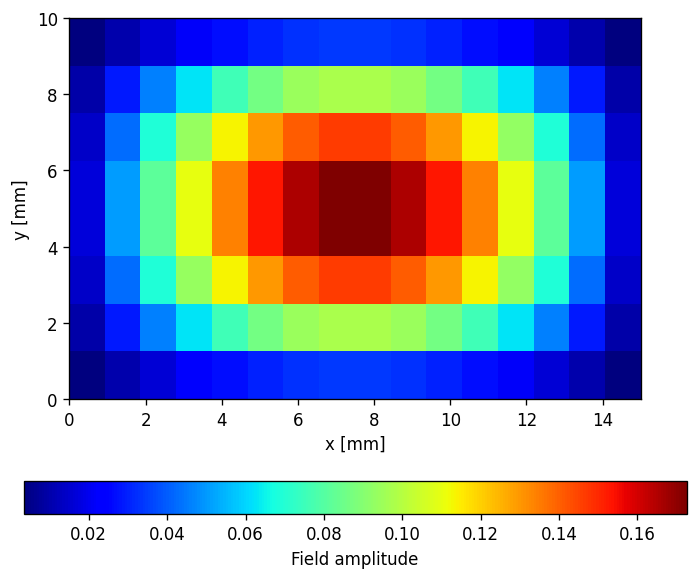

In [11]:
solver_tm = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM',
    Lx=Lx, Ly=Ly,
    plasma_density=0.0   # Vacuum
)

print('Solving TM mode 0 (fundamental)...')
eigenvalue_0, params_0, history_0 = solver_tm.optimize_mode(k=0)
solver_tm.print_plot_parameters(0, eigenvalue_0, params_0)

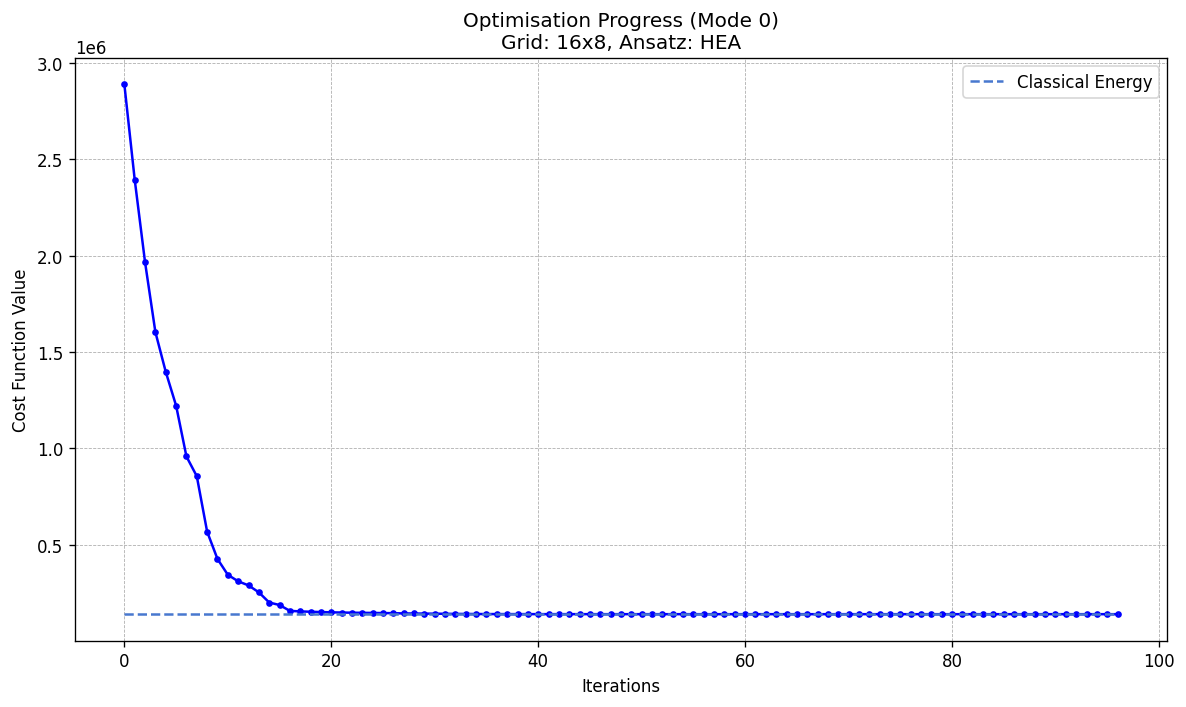

In [12]:
# Convergence plot
solver_tm.plot_converge(history_0, k=0)

### Second TM mode


Solving TM mode 1 (first excited)...
Attempt 1 - Iter 212: Cost 270650.7521    
Mode 1 Result:
Eigenvalue λ = ω²/c² : 270650.752140630 m⁻²
Cutoff Freq : 24.822496249 GHz

Numerical Eigenvalue (dense) : 270650.551070980 m⁻²
Cutoff / wave freq (numerical): 24.822487028 GHz
Relative Error vs numerical   : 0.000037146%
Relative Error vs theoretical : 0.641258756%


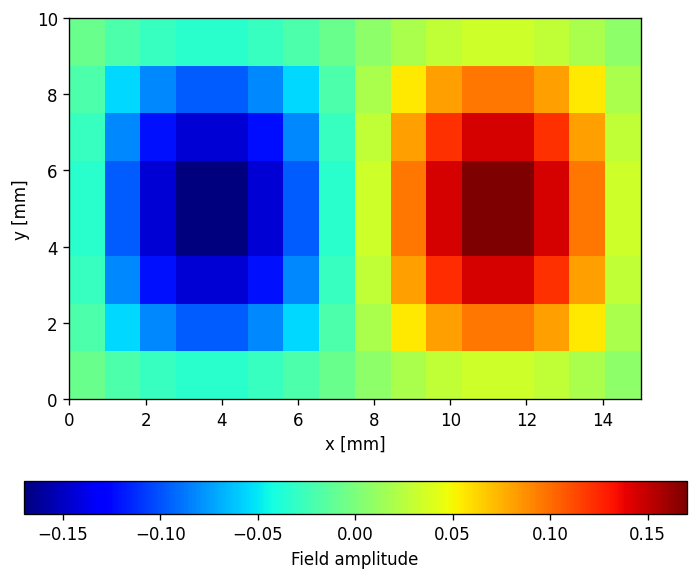

In [14]:
print('\nSolving TM mode 1 (first excited)...')
eigenvalue_1, params_1, history_1 = solver_tm.optimize_mode(k=1)
solver_tm.print_plot_parameters(1, eigenvalue_1, params_1)

## 3. TE Modes (Neumann Boundary Conditions)

TE modes have $\partial E_z / \partial n = 0$ on the walls.
The first non-trivial TE mode is TE₁₀.

Solving TE mode 0 (fundamental)...
Attempt 1 - Iter 218: Cost 43724.4302    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 43724.430218514 m⁻²
Cutoff Freq : 9.977067581 GHz

Numerical Eigenvalue (dense) : 43724.161926873 m⁻²
Cutoff / wave freq (numerical): 9.977036971 GHz
Relative Error vs numerical   : 0.000306800%
Relative Error vs theoretical : 0.160434891%


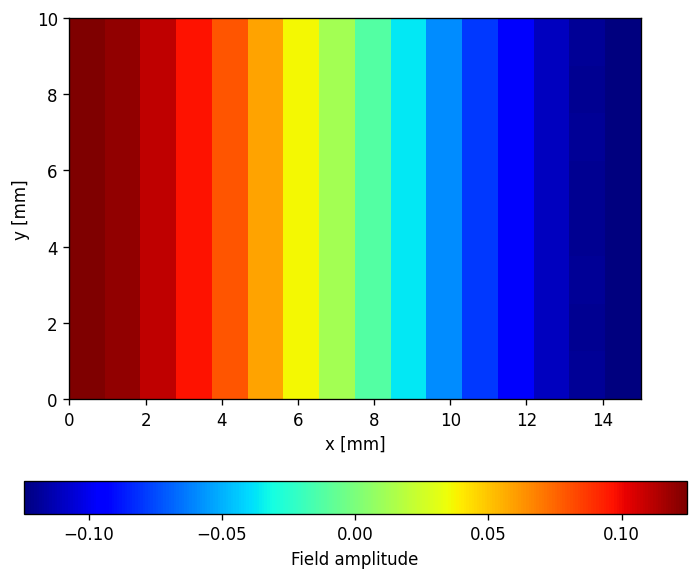

In [4]:
solver_te = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TE',
    Lx=Lx, Ly=Ly,
    plasma_density=0.0
)

print('Solving TE mode 0 (fundamental)...')
eigenvalue_te0, params_te0, history_te0 = solver_te.optimize_mode(k=0)
solver_te.print_plot_parameters(0, eigenvalue_te0, params_te0)

### Second TE mode


Solving TE mode 1 (first excited)...
Attempt 1 - Iter 248: Cost 97434.2021    
Mode 1 Result:
Eigenvalue λ = ω²/c² : 97434.202093414 m⁻²
Cutoff Freq : 14.893492500 GHz

Numerical Eigenvalue (dense) : 97434.198385553 m⁻²
Cutoff / wave freq (numerical): 14.893492217 GHz
Relative Error vs numerical   : 0.000001903%
Relative Error vs theoretical : 0.641161202%


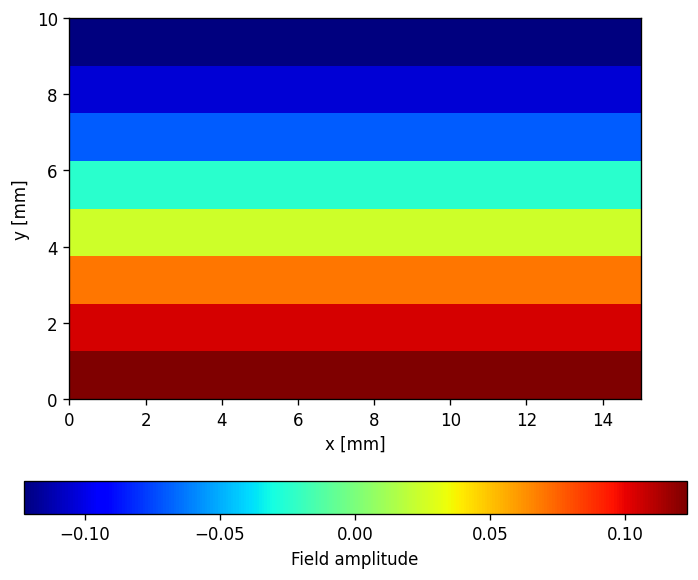

In [5]:
print('\nSolving TE mode 1 (first excited)...')
eigenvalue_te1, params_te1, history_te1 = solver_te.optimize_mode(k=1)
solver_te.print_plot_parameters(1, eigenvalue_te1, params_te1)

## 4. Classical Comparison

Verify VQE results against exact diagonalisation of the finite-difference matrix.

In [9]:
# Classical eigenvalues (TM)
eigs_tm = np.sort(np.linalg.eigvalsh(solver_tm.M_dense))
eigs_tm_pos = [e for e in eigs_tm if e > 0]

# Classical eigenvalues (TE)
eigs_te = np.sort(np.linalg.eigvalsh(solver_te.M_dense))
eigs_te_pos = [e for e in eigs_te if e > 1]

c = 299792458
print('Classical TM eigenvalues (first 4):')
for i, e in enumerate(eigs_tm_pos[:4]):
    f = c * np.sqrt(e) / (2 * np.pi * 1e9)
    print(f'  Mode {i}: lambda = {e:.4f} m^-2  ->  f = {f:.4f} GHz')

print('\nClassical TE eigenvalues (first 4):')
for i, e in enumerate(eigs_te_pos[:4]):
    f = c * np.sqrt(e) / (2 * np.pi * 1e9)
    print(f'  Mode {i}: lambda = {e:.4f} m^-2  ->  f = {f:.4f} GHz')

Classical TM eigenvalues (first 4):
  Mode 0: lambda = 141158.3603 m^-2  ->  f = 17.9264 GHz
  Mode 1: lambda = 270650.5511 m^-2  ->  f = 24.8225 GHz
  Mode 2: lambda = 418627.4820 m^-2  ->  f = 30.8713 GHz
  Mode 3: lambda = 480934.4584 m^-2  ->  f = 33.0890 GHz

Classical TE eigenvalues (first 4):
  Mode 0: lambda = 43724.1619 m^-2  ->  f = 9.9770 GHz
  Mode 1: lambda = 97434.1984 m^-2  ->  f = 14.8935 GHz
  Mode 2: lambda = 141158.3603 m^-2  ->  f = 17.9264 GHz
  Mode 3: lambda = 173216.3527 m^-2  ->  f = 19.8580 GHz


## 5. Save Parameters

We can save the parameters in order to do a not ML Warm start from a previously calculated mode for each type of wave.

In [ ]:
solver_tm.save_all_results()
solver_te.save_all_results()
print('Parameters saved.')